In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Imposto il seed del generatore pseudo-casuale per garantire la riproducibilità del dataset
np.random.seed(42)

# Genero la feature indipendente X (dimensione 100x1).
# np.random.rand(100, 1) campiona da una distribuzione uniforme nell'intervallo [0, 1).
# Moltiplico per 10 per effettuare il riscalamento lineare nell'intervallo [0, 10).
X = 10 * np.random.rand(100, 1)

# Verifico la consistenza dimensionale del vettore colonna (Input Tensor shape)
print(f"Shape del vettore X: {X.shape}")

Shape del vettore X: (100, 1)


In [2]:
# Genero il rumore stocastico da sommare alla relazione lineare.
# np.random.randn(100, 1) campiona da una distribuzione normale standard (media=0, varianza=1).
# Moltiplico per 2.5 per riscalare la deviazione standard e aumentare la dispersione dei dati.
rumore = np.random.randn(100, 1) * 2.5

# Calcolo il vettore target y applicando la funzione lineare: y = w * X + b + rumore.
# Imposto i parametri reali ground-truth: peso (w) = 3.5 e bias (b) = 12.0.
y = 3.5 * X + 12.0 + rumore

# Verifico la consistenza dimensionale del vettore target
print(f"Shape del vettore y: {y.shape}")

Shape del vettore y: (100, 1)


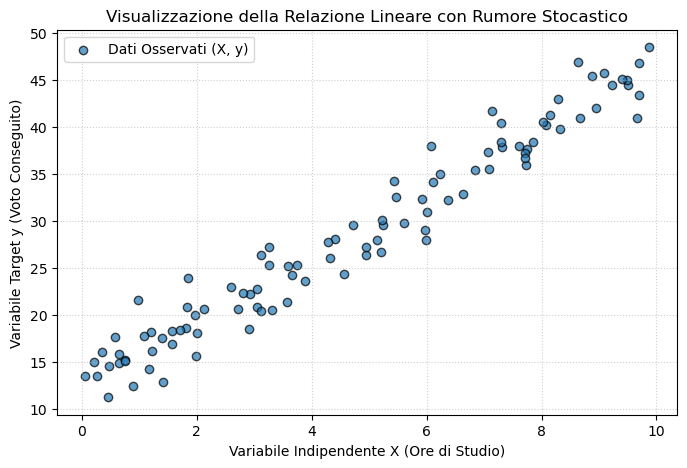

In [3]:
# Inizializzo la figura definendo le dimensioni in pollici (larghezza, altezza)
plt.figure(figsize=(8, 5))

# Genero un grafico a dispersione (scatter plot) per mappare la nuvola dei dati.
# alpha=0.7 imposta la trasparenza per identificare eventuali sovrapposizioni di punti.
# edgecolors='k' (black) evidenzia i contorni dei punti per una migliore leggibilità.
plt.scatter(X, y, color='#1f77b4', alpha=0.7, edgecolors='k', label='Dati Osservati (X, y)')

# Definisco le etichette degli assi e il titolo del grafico
plt.xlabel('Variabile Indipendente X (Ore di Studio)')
plt.ylabel('Variabile Target y (Voto Conseguito)')
plt.title('Visualizzazione della Relazione Lineare con Rumore Stocastico')

# Attivo la griglia di sfondo con stile puntinato per facilitare la lettura dei valori
plt.grid(True, linestyle=':', alpha=0.6)

# Mostro la legenda per identificare la tipologia di dato plottata
plt.legend()

# Rendering del grafico all'inte

In [4]:
# ==============================================================================
# INIZIALIZZAZIONE PARAMETRI (I pesi che l'algoritmo deve ottimizzare)
# ==============================================================================
# Imposto il peso (w) e il bias (b) strutturalmente a 0.0.
# Geometricamente, la retta iniziale del modello sarà una retta piatta sullo zero: y = 0*X + 0
w = 0.0
b = 0.0

# ==============================================================================
# CONFIGURAZIONE IPERPARAMETRI (Le impostazioni di controllo dell'algoritmo)
# ==============================================================================
# Learning Rate (alfa): Controlla la dimensione del passo lungo il gradiente.
# Un valore di 0.01 è uno standard sicuro per questo tipo di problema riscalato.
learning_rate = 0.01

# Epoche: Il numero di passaggi completi che l'algoritmo farà sull'intero dataset.
epoche = 400

# n: La cardinalità (dimensione) del dataset, estratta dinamicamente da X.
# Sarà il denominatore fondamentale per calcolare la media dell'errore e dei gradienti.
n = len(X)

print(f"Modello inizializzato con successo.")
print(f"Stato iniziale -> Pendenza (w): {w} | Intercetta (b): {b}")
print(f"Iperparametri -> Learning Rate: {learning_rate} | Epoche: {epoche} | Campioni (n): {n}")

Modello inizializzato con successo.
Stato iniziale -> Pendenza (w): 0.0 | Intercetta (b): 0.0
Iperparametri -> Learning Rate: 0.01 | Epoche: 400 | Campioni (n): 100


In [5]:
def calcola_mse(X, y, w, b):
    """
    Calcola l'Errore Quadratico Medio (MSE) del modello.
    Formula matematica: MSE = (1 / n) * somma( (y_pred - y)^2 )
    """
    # 1. Forward Pass: calcolo le predizioni attuali del modello sfruttando i vettori NumPy
    # Se X ha shape (100,1), anche y_pred sarà un vettore (100,1)
    y_pred = w * X + b

    # 2. Calcolo i residui (la differenza puntuale tra il voto previsto e il voto reale)
    residui = y_pred - y

    # 3. Elevo al quadrato i residui per eliminare i segni negativi e penalizzare gli errori grandi
    residui_quadrati = residui ** 2

    # 4. Calcolo la media aritmetica degli errori quadratici sfruttando np.mean
    mse = np.mean(residui_quadrati)

    return mse

# Testiamo subito la funzione per valutare l'errore a Epoca 0 (prima dell'addestramento)
errore_iniziale = calcola_mse(X, y, w, b)
print(f"Errore Quadratico Medio iniziale (Epoca 0): {errore_iniziale:.2f}")

Errore Quadratico Medio iniziale (Epoca 0): 915.04


In [6]:
# Inizializzo una lista per salvare la storia dell'errore e monitorare la convergenza
storia_loss = []

print("Inizio l'addestramento del modello...")
print("-" * 50)

for epoca in range(epoche):
    # 1. Forward Pass: Calcolo le predizioni attuali del modello
    y_pred = w * X + b

    # 2. Calcolo dei Gradienti (Derivate Parziali dell'MSE)
    # d_w = (2/n) * somma( (y_pred - y) * X )
    # d_b = (2/n) * somma( y_pred - y )
    d_w = (2 / n) * np.sum((y_pred - y) * X)
    d_b = (2 / n) * np.sum(y_pred - y)

    # 3. Aggiornamento dei Parametri (Gradient Descent Step)
    # Muovo i parametri nella direzione opposta al gradiente per scendere verso il minimo
    w = w - (learning_rate * d_w)
    b = b - (learning_rate * d_b)

    # 4. Tracciamento della Loss corrente per l'analisi post-addestramento
    loss_corrente = calcola_mse(X, y, w, b)
    storia_loss.append(loss_corrente)

    # Stampo lo stato dell'ottimizzazione ogni 40 epoche per monitorare il processo
    if epoca % 40 == 0 or epoca == epoche - 1:
        print(f"Epoca {epoca:03d} -> Loss: {loss_corrente:.4f} | w ottimizzato: {w:.4f} | b ottimizzato: {b:.4f}")

print("-" * 50)
print("Addestramento completato!")
print(f"Valori finali calcolati dal mio modello -> w: {w:.4f}, b: {b:.4f}")
print(f"Valori reali (Ground Truth) impostati all'inizio -> w: 3.5000, b: 12.0000")

Inizio l'addestramento del modello...
--------------------------------------------------
Epoca 000 -> Loss: 161.7880 | w ottimizzato: 3.2688 | b ottimizzato: 0.5691
Epoca 040 -> Loss: 29.8390 | w ottimizzato: 4.8215 | b ottimizzato: 3.1916
Epoca 080 -> Loss: 20.9326 | w ottimizzato: 4.5350 | b ottimizzato: 5.0560
Epoca 120 -> Loss: 15.2250 | w ottimizzato: 4.3056 | b ottimizzato: 6.5484
Epoca 160 -> Loss: 11.5673 | w ottimizzato: 4.1220 | b ottimizzato: 7.7431
Epoca 200 -> Loss: 9.2234 | w ottimizzato: 3.9750 | b ottimizzato: 8.6995
Epoca 240 -> Loss: 7.7213 | w ottimizzato: 3.8573 | b ottimizzato: 9.4652
Epoca 280 -> Loss: 6.7587 | w ottimizzato: 3.7631 | b ottimizzato: 10.0781
Epoca 320 -> Loss: 6.1418 | w ottimizzato: 3.6877 | b ottimizzato: 10.5687
Epoca 360 -> Loss: 5.7465 | w ottimizzato: 3.6273 | b ottimizzato: 10.9615
Epoca 399 -> Loss: 5.4982 | w ottimizzato: 3.5801 | b ottimizzato: 11.2689
--------------------------------------------------
Addestramento completato!
Valori fin

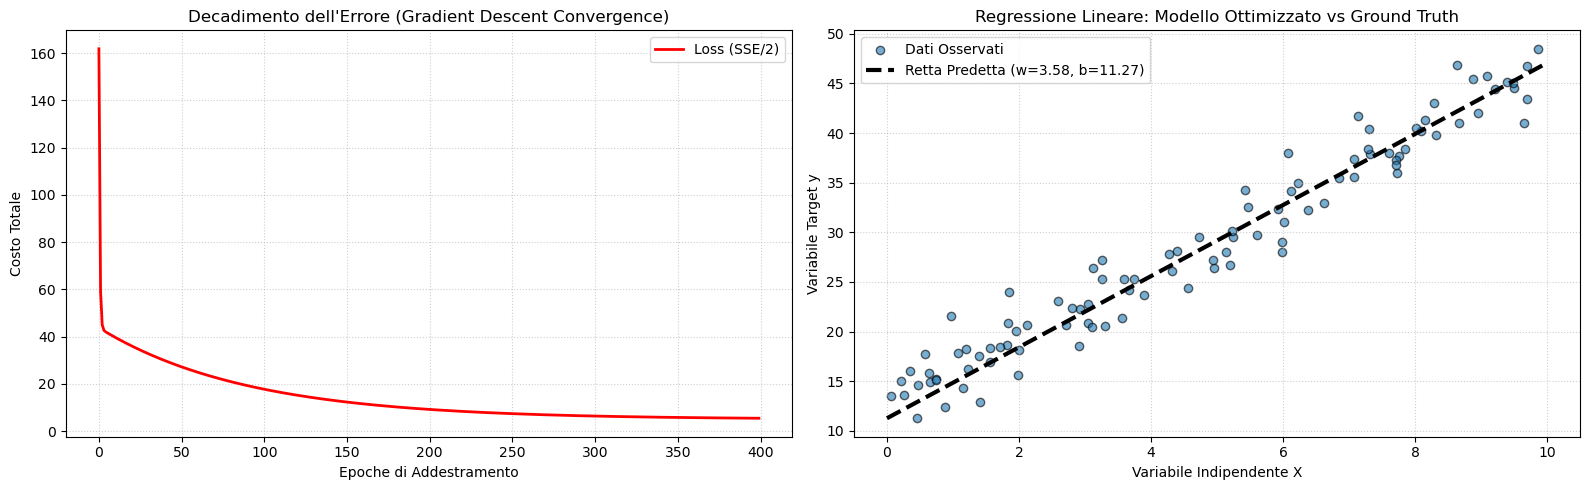

In [7]:
# Inizializzo un pannello con due sotto-grafici (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ==============================================================================
# GRAFICO 1: CURVA DI CONVERGENZA DELLA LOSS
# ==============================================================================
# Traccio l'andamento del costo rispetto alle epoche per verificare la stabilità
ax1.plot(storia_loss, color='red', linewidth=2, label='Loss (SSE/2)')
ax1.set_xlabel('Epoche di Addestramento')
ax1.set_ylabel('Costo Totale')
ax1.set_title('Decadimento dell\'Errore (Gradient Descent Convergence)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# ==============================================================================
# GRAFICO 2: OVERLAY DELLA RETTA OTTIMIZZATA SUI DATI ORIGINARI
# ==============================================================================
# Rappresento la nuvola di punti sperimentale
ax2.scatter(X, y, color='#1f77b4', alpha=0.6, edgecolors='k', label='Dati Osservati')

# Calcolo i punti della retta di regressione usando i parametri w e b ottimizzati
X_linea = np.array([0, 10])
y_linea = w * X_linea + b

# Sovrappongo la retta ottimizzata dal modello
ax2.plot(X_linea, y_linea, color='black', linestyle='--', linewidth=3,
         label=f'Retta Predetta (w={w:.2f}, b={b:.2f})')
ax2.set_xlabel('Variabile Indipendente X')
ax2.set_ylabel('Variabile Target y')
ax2.set_title('Regressione Lineare: Modello Ottimizzato vs Ground Truth')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
# 1. Calcolo le predizioni finali del modello ottimizzato
y_pred_finali = w * X + b

# 2. Calcolo il Root Mean Squared Error (RMSE)
# È semplicemente la radice quadrata dell'MSE standard (diviso n)
mse_finale = np.mean((y_pred_finali - y) ** 2)
rmse = np.sqrt(mse_finale)

# 3. Calcolo il coefficiente R² (R-squared)
# Formula: 1 - (Somma dei quadrati dei residui / Somma dei quadrati totali rispetto alla media)
somma_residui = np.sum((y - y_pred_finali) ** 2)
somma_totale = np.sum((y - np.mean(y)) ** 2)
r2_score = 1 - (somma_residui / somma_totale)

print("METRICHE DI VALUTAZIONE FINALI:")
print("-" * 35)
print(f"RMSE (Errore medio): {rmse:.2f} punti di voto")
print(f"R² Score (Accuratezza): {r2_score:.4f} ({r2_score*100:.2f}%)")

METRICHE DI VALUTAZIONE FINALI:
-----------------------------------
RMSE (Errore medio): 2.34 punti di voto
R² Score (Accuratezza): 0.9479 (94.79%)
